# Time Series Forecasting with LSTMs

## Why use neural networks for time series?

In the classical time series notebook we used ARIMA to forecast airline passengers. ARIMA works well there because the series is relatively short, mostly stationary after differencing, and univariate. But ARIMA carries real limitations:

- It assumes the relationship between past values and the future is **linear**. If the true pattern is non-linear, ARIMA cannot capture it regardless of how carefully you tune the order parameters.
- It requires **stationarity** — you have to transform the data before fitting (differencing, log transforms) and undo those transforms after predicting.
- It only accepts **one input series**. If you have weather data, economic indicators, and traffic counts all influencing the same outcome, ARIMA cannot use them together.
- It requires **manual lag selection**: you inspect ACF and PACF plots and pick p, d, q by hand.

LSTMs address all four of these:

- They learn **non-linear** temporal patterns directly from data.
- They do not require stationarity — simple min-max normalization is usually sufficient.
- They accept **multiple input features** at each timestep naturally.
- The architecture itself acts as a memory mechanism; lag structure is learned, not specified.

The tradeoff is real, though. LSTMs need **much more data** to generalize, take **much longer to train**, and are harder to interpret. On a short, seasonal, univariate series — like airline passengers — ARIMA will often beat or tie an LSTM. LSTMs begin to pull ahead when the series is long, multivariate, or contains non-linear interactions that a linear model simply cannot represent.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from tensorflow.keras import layers, models

import ipywidgets as widgets
from IPython.display import display

## The airline passengers dataset

We will use the same dataset as the classical time series notebook: monthly international airline passengers from 1949 to 1960, 144 observations.

<Figure size 1200x400 with 0 Axes>

Text(0.5, 1.0, 'Monthly International Airline Passengers')

Text(0, 0.5, 'Passengers (thousands)')

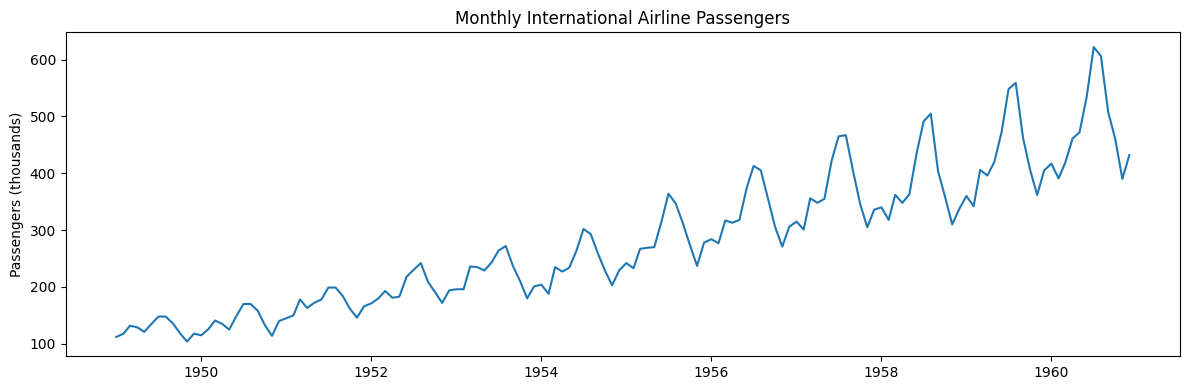

In [3]:
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
data.index = pd.date_range(start='1949-01', periods=len(data), freq='MS')
series = data['value'].values.astype(float)

plt.figure(figsize=(12, 4))
plt.plot(data.index, series)
plt.title('Monthly International Airline Passengers')
plt.ylabel('Passengers (thousands)')
plt.tight_layout()
plt.show()

## Framing time series as a supervised learning problem

The key conceptual shift from classical time series methods to neural networks is this: we turn the forecasting problem into a standard supervised learning problem.

In supervised learning, each training example is an `(X, y)` pair: a vector of input features and a target value. For a time series, we create those pairs by sliding a window of fixed width across the series:

- **Input X**: the last `n_steps` observed values
- **Target y**: the value immediately after that window

We slide this window forward one step at a time, generating one training example per position. This is called the **sliding window** or **lag feature** approach.

Here is a concrete example with a tiny series and `n_steps = 3`:

In [4]:
tiny = [10, 20, 30, 40, 50, 60, 70]
n_steps = 3

rows = []
for i in range(len(tiny) - n_steps):
    window = tiny[i : i + n_steps]
    target = tiny[i + n_steps]
    rows.append({'X (input window)': str(window), 'y (target)': target})

pd.DataFrame(rows)

,X (input window),y (target)
0,"[10, 20, 30]",40
1,"[20, 30, 40]",50
2,"[30, 40, 50]",60
3,"[40, 50, 60]",70


The table above shows exactly what we are doing. The model will learn to predict the last column given any row of the first column. Once we have that mapping, we can slide the window forward in time to generate forecasts.

For an LSTM the input needs one more dimension: `(samples, timesteps, features)`. Each sample is one window, each timestep is one position within the window, and each feature is the value at that position. For a univariate series, features = 1. The reshape below handles that.

In [5]:
def make_windows(series, n_steps):
    """Create (X, y) pairs from a 1-D series using a sliding window."""
    X, y = [], []
    for i in range(len(series) - n_steps):
        X.append(series[i : i + n_steps])
        y.append(series[i + n_steps])
    X = np.array(X).reshape(-1, n_steps, 1)   # (samples, timesteps, 1 feature)
    y = np.array(y)
    return X, y

## LSTM for univariate forecasting

Now we prepare the airline data and train an LSTM on it.

**Two preprocessing steps before we build windows:**

1. **Normalize to [0, 1].** Neural networks train faster and more stably when inputs are on a consistent scale. We store the min and max from the training set and apply the same scale to the test set — using test statistics would leak information.

2. **Train/test split.** We hold out the last 24 months as a test set, matching the ARIMA notebook. Everything before that is training data.

The LSTM architecture is intentionally simple:
- One LSTM layer with 32 units
- A single Dense output neuron (we are regressing to one future value)
- Mean squared error loss, Adam optimizer

In [6]:
TEST_MONTHS = 24
N_STEPS = 12   # default window; the interactive widget below will vary this

train_raw = series[: -TEST_MONTHS]
test_raw  = series[-TEST_MONTHS :]

# Normalize using training statistics only
train_min, train_max = train_raw.min(), train_raw.max()
train_norm = (train_raw - train_min) / (train_max - train_min)
test_norm  = (test_raw  - train_min) / (train_max - train_min)

X_train, y_train = make_windows(train_norm, N_STEPS)
X_test,  y_test  = make_windows(test_norm,  N_STEPS)

print(f'Training windows : {X_train.shape}   targets: {y_train.shape}')
print(f'Test windows     : {X_test.shape}   targets: {y_test.shape}')

Training windows : (108, 12, 1)   targets: (108,)
Test windows     : (12, 12, 1)   targets: (12,)


In [7]:
tf.random.set_seed(42)

def build_lstm(n_steps, units=32):
    model = models.Sequential([
        layers.Input(shape=(n_steps, 1)),
        layers.LSTM(units),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm(N_STEPS)
lstm_model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 lstm (LSTM)                 (None, 32)                4352      


 dense (Dense)               (None, 1)                 33        


Total params: 4385 (17.13 KB)


Trainable params: 4385 (17.13 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


<Figure size 1000x400 with 0 Axes>

Text(0.5, 1.0, 'LSTM Training Curve')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'MSE (normalized scale)')

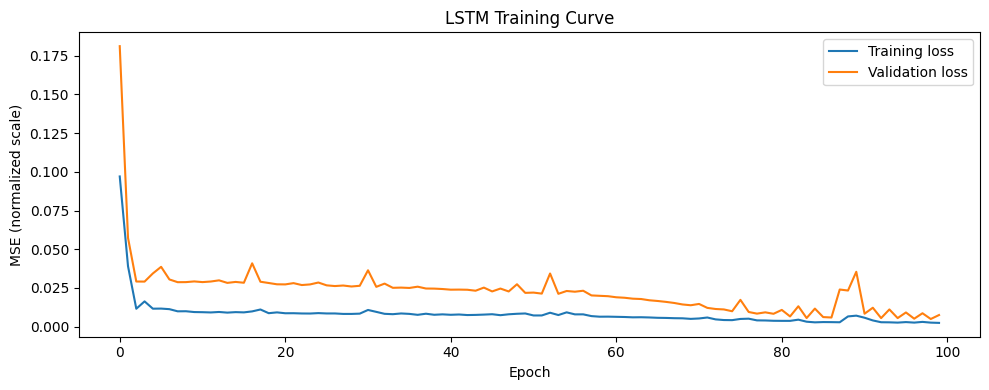

In [8]:
history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=0
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('LSTM Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized scale)')
plt.legend()
plt.tight_layout()
plt.show()

LSTM test RMSE: 57.6 passengers


<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'LSTM Forecast vs Actuals (n_steps=12)')

Text(0, 0.5, 'Passengers (thousands)')

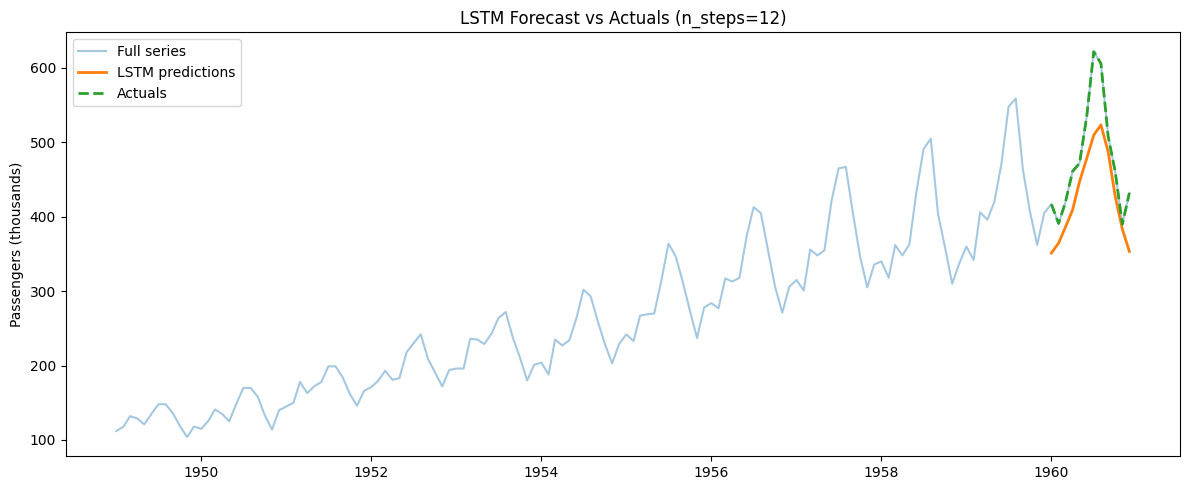

In [9]:
# Predict on test windows and rescale back to original passenger counts
y_pred_norm = lstm_model.predict(X_test, verbose=0).flatten()
y_pred = y_pred_norm * (train_max - train_min) + train_min
y_true = y_test      * (train_max - train_min) + train_min

lstm_rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
print(f'LSTM test RMSE: {lstm_rmse:.1f} passengers')

# Build a date index aligned to the test predictions
# The first test window consumes N_STEPS values, so predictions start at position N_STEPS
test_dates = data.index[-TEST_MONTHS + N_STEPS :]

plt.figure(figsize=(12, 5))
plt.plot(data.index, series, label='Full series', alpha=0.4)
plt.plot(test_dates, y_pred, label='LSTM predictions', linewidth=2)
plt.plot(test_dates, y_true, label='Actuals', linewidth=2, linestyle='--')
plt.title(f'LSTM Forecast vs Actuals (n_steps={N_STEPS})')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.tight_layout()
plt.show()

The LSTM picks up the general upward trend and the seasonal pattern, though on only 144 data points it has limited data to generalize from.

## Comparing ARIMA and LSTM

How does this compare to the classical approach? We will fit a seasonal ARIMA on the same training data, generate test-period forecasts, and compare test RMSEs side-by-side.

The ARIMA order `(2, 1, 2)` with a seasonal component `(1, 1, 1, 12)` is a reasonable fit for this dataset — see the classical time series notebook for the diagnostic reasoning behind it.

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima_model = SARIMAX(
    train_raw,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_forecast = arima_model.forecast(steps=TEST_MONTHS)
arima_rmse = np.sqrt(np.mean((np.asarray(arima_forecast) - test_raw) ** 2))
print(f'SARIMA test RMSE : {arima_rmse:.1f} passengers')
print(f'LSTM   test RMSE : {lstm_rmse:.1f} passengers')

SARIMA test RMSE : 43.2 passengers
LSTM   test RMSE : 57.6 passengers


<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'SARIMA vs LSTM — Airline Passengers Test Set')

Text(0, 0.5, 'Passengers (thousands)')

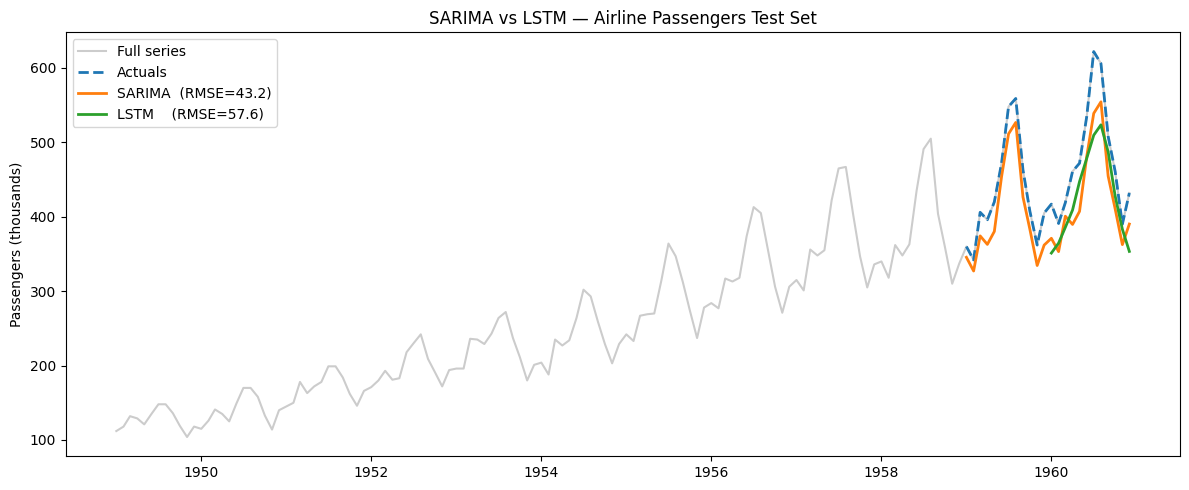

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, series, label='Full series', alpha=0.4, color='gray')
plt.plot(data.index[-TEST_MONTHS:], test_raw,    label='Actuals', linewidth=2, linestyle='--')
plt.plot(data.index[-TEST_MONTHS:], arima_forecast, label=f'SARIMA  (RMSE={arima_rmse:.1f})', linewidth=2)
plt.plot(test_dates,                y_pred,          label=f'LSTM    (RMSE={lstm_rmse:.1f})', linewidth=2)
plt.title('SARIMA vs LSTM — Airline Passengers Test Set')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.tight_layout()
plt.show()

### What the comparison tells us

On this dataset, SARIMA almost certainly wins or ties. That is expected:

- The airline series has **144 data points** — far too few for an LSTM to generalize reliably.
- The relationship between past and future values here is effectively **linear** (the exponential-looking trend becomes linear after log-differencing), so ARIMA's linear assumption is a good fit.
- SARIMA directly encodes the 12-month seasonality via the seasonal order; the LSTM has to discover that pattern from data.

LSTMs begin to outperform ARIMA when:
- The series is **long** (thousands of timesteps, not hundreds)
- There are **non-linear dependencies** between past and future values
- You have **multiple input series** (covariates)
- The patterns **change over time** in complex ways

## Multivariate time series

One place LSTMs clearly win over ARIMA: when you have **multiple input series**.

ARIMA is fundamentally univariate (ARIMAX adds exogenous regressors, but the framework is clunky for genuinely multivariate forecasting). An LSTM handles multiple inputs trivially: instead of one value per timestep, you stack all your features into a vector. The input shape becomes `(samples, timesteps, n_features)` and nothing else changes.

The cell below builds a toy multivariate dataset — two synthetic features — to illustrate the data shape and model architecture. We are not training to convergence here; the goal is to show that the transition from univariate to multivariate is just one number in the input shape.

In [12]:
np.random.seed(0)
n = 300
t = np.linspace(0, 4 * np.pi, n)

# Feature 1: a noisy sine wave
f1 = np.sin(t) + 0.1 * np.random.randn(n)
# Feature 2: a lagged cosine (a different rhythm)
f2 = np.cos(t + np.pi / 4) + 0.1 * np.random.randn(n)
# Target: a combination that neither feature predicts alone
target = np.sin(t) * np.cos(t) + 0.05 * np.random.randn(n)

mv_series = np.column_stack([f1, f2])   # shape (300, 2)

MV_STEPS = 12

def make_mv_windows(features, target, n_steps):
    X, y = [], []
    for i in range(len(target) - n_steps):
        X.append(features[i : i + n_steps, :])    # (n_steps, n_features)
        y.append(target[i + n_steps])
    return np.array(X), np.array(y)

X_mv, y_mv = make_mv_windows(mv_series, target, MV_STEPS)
print(f'Multivariate X shape: {X_mv.shape}   (samples, timesteps, features)')
print(f'Target y shape      : {y_mv.shape}')

Multivariate X shape: (288, 12, 2)   (samples, timesteps, features)
Target y shape      : (288,)


In [13]:
n_features = mv_series.shape[1]

mv_model = models.Sequential([
    layers.Input(shape=(MV_STEPS, n_features)),
    layers.LSTM(32),
    layers.Dense(1)
])
mv_model.compile(optimizer='adam', loss='mse')
mv_model.summary()

Model: "sequential_1"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 lstm_1 (LSTM)               (None, 32)                4480      


 dense_1 (Dense)             (None, 1)                 33        


Total params: 4513 (17.63 KB)


Trainable params: 4513 (17.63 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


The only difference from the univariate model is the input shape: `(12, 2)` instead of `(12, 1)`. The LSTM layer, loss function, and output layer are identical. This composability is one reason LSTMs are attractive for multivariate forecasting — the architecture scales to any number of features without structural changes.

A practical alternative worth knowing: **gradient boosted trees on lag features**. Instead of an LSTM, you manually create lag columns (`feature_t-1`, `feature_t-2`, …) and fit XGBoost or LightGBM on the resulting wide table. This often matches or beats LSTMs on tabular multivariate data, trains faster, and is easier to interpret.

## Interactive widget: how does window size affect forecasting?

The **window size** (`n_steps`) is the primary hyperparameter in the sliding-window approach. A larger window gives the model more context — it can see further back in the past — but it also reduces the number of training examples and makes training slower.

Use the slider below to try different window sizes. For each setting, the widget:
1. Creates the sliding-window dataset from the normalized airline series
2. Trains a small LSTM (20 epochs — just enough to learn a reasonable pattern quickly)
3. Plots predictions vs actuals on the test set
4. Reports the test RMSE

**What to watch for:** very small windows give the model too little context (the predictions will lag or miss the seasonal peaks); very large windows consume most of the short series and leave little training data.

In [14]:
def run_lstm_experiment(n_steps):
    tf.random.set_seed(42)

    # Rebuild normalized train/test with new window size
    X_tr, y_tr = make_windows(train_norm, n_steps)
    X_te, y_te = make_windows(test_norm,  n_steps)

    if len(X_tr) < 5:
        print('Window too large — not enough training examples.')
        return

    m = build_lstm(n_steps)
    m.fit(X_tr, y_tr, epochs=20, batch_size=16, verbose=0)

    pred_norm = m.predict(X_te, verbose=0).flatten()
    pred = pred_norm * (train_max - train_min) + train_min
    true = y_te      * (train_max - train_min) + train_min

    rmse = np.sqrt(np.mean((pred - true) ** 2))

    pred_dates = data.index[-TEST_MONTHS + n_steps :]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(data.index, series, alpha=0.3, color='gray', label='Full series')
    ax.plot(pred_dates, true, linewidth=2, linestyle='--', label='Actuals')
    ax.plot(pred_dates, pred, linewidth=2, label=f'LSTM forecast')
    ax.set_title(f'LSTM Forecast — window = {n_steps} months   |   Test RMSE = {rmse:.1f} passengers')
    ax.set_ylabel('Passengers (thousands)')
    ax.legend()
    plt.tight_layout()
    plt.show()

window_slider = widgets.IntSlider(
    value=12, min=6, max=36, step=6,
    description='n_steps:',
    style={'description_width': 'initial'}
)
widgets.interact(run_lstm_experiment, n_steps=window_slider)

interactive(children=(IntSlider(value=12, description='n_steps:', max=36, min=6, step=6, style=SliderStyle(des…

<function __main__.run_lstm_experiment(n_steps)>

## Practical guidance: when to use which

There is no single best method for time series forecasting. The right tool depends on your data and constraints:

| Situation | Recommended approach |
|-----------|----------------------|
| Short series (< 200 observations), stationary or easily differenced, univariate | **ARIMA / SARIMA** — fast to fit, interpretable, often hard to beat |
| Long series (thousands of points), clear non-linear patterns | **LSTM** or other RNN architectures |
| Multiple correlated input series | **LSTM** or **gradient boosted trees on lag features** |
| Need a forecast in seconds, or interpretability is critical | **ARIMA** — minutes of analysis vs hours of training |
| Large-scale, production forecasting across many series | **LightGBM / XGBoost on lag features** — often the pragmatic sweet spot |

A useful rule of thumb: start with ARIMA. It is fast, explainable, and provides a hard-to-beat baseline on most short series. Reach for an LSTM when the baseline clearly underperforms and you have enough data to justify the cost.

For very large-scale forecasting (thousands of related series — think retail demand forecasting), neither ARIMA nor standard LSTMs are usually the right answer. Transformer-based models (Temporal Fusion Transformer, PatchTST) and tree-based approaches on lag features are the current state of the art.